In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("../data/city_day.csv")
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
df.shape

(29531, 16)

In [4]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  object        
dtypes: datetime64[ns](1), 

In [8]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [9]:
df = df.fillna(method='ffill')

C:\Users\deltajoe\AppData\Local\Temp\ipykernel_19704\569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [10]:
df = df.drop_duplicates()

In [11]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,29531,29504.000000,27937.000000,29531.000000,29531.000000,29531.000000,27522.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29503.000000
mean,2018-05-14 05:40:15.807118080,66.130899,95.070437,17.201890,26.909513,32.611069,22.359410,2.292734,15.650236,34.130603,3.130408,7.027591,2.864628,162.865268
min,2015-01-01 00:00:00,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,2017-04-16 00:00:00,29.160000,31.580000,5.900000,11.630000,13.180000,7.820000,0.500000,5.740000,18.860000,0.050000,0.280000,0.180000,76.000000
50%,2018-08-05 00:00:00,46.850000,72.380000,9.280000,19.720000,21.980000,13.395000,0.910000,8.950000,31.480000,0.670000,1.720000,1.250000,113.000000
75%,2019-09-03 00:00:00,78.652500,122.290000,18.560000,35.030000,38.660000,25.500000,1.490000,15.840000,44.215000,2.750000,6.710000,2.695000,205.000000
max,2020-07-01 00:00:00,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000
std,NaN,64.130750,86.577554,23.245966,23.671982,33.829601,26.695912,6.824266,20.583528,21.631257,15.988058,17.841550,5.383474,138.545194


In [12]:
# AQI Trend over time in India
aqi_trend = df.groupby("Date")["AQI"].mean().reset_index()

In [13]:
aqi_trend.head()

,Date,AQI
0,2015-01-01,147.400000
1,2015-01-02,143.800000
2,2015-01-03,81.600000
3,2015-01-04,103.333333
4,2015-01-05,104.333333


In [14]:
# Line chart
fig = px.line(
    aqi_trend,
    x="Date",
    y="AQI",
    title="AQI Trend Over Time in India",
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average AQI",
    template="plotly_dark"
)
fig.show()

In [15]:
fig.write_html("../visuals/aqi_trend.html")

In [16]:
# Top 10 Most Polluted Cities in India
city_aqi = df.groupby("City")["AQI"].mean().reset_index()

In [17]:
city_aqi = city_aqi.sort_values(by="AQI", ascending=False)

In [18]:
top_cities = city_aqi.head(10)

In [19]:
#Bar chart
fig = px.bar(
    top_cities,
    x="City",
    y="AQI",
    title="Top 10 Most Polluted Cities in India",
    color="AQI",
    color_continuous_scale="Reds"
)
fig.update_layout(
    xaxis_title="City",
    yaxis_title="Average AQI",
    template="plotly_dark"
)
fig.show()


In [20]:
fig.write_html("../visuals/top_polluted_cities.hmtl")

In [21]:
# AQI Trend Comparison Across Major Cities in India
cities = ["Delhi", "Mumbai", "Kolkata", "Chennai", "Bengaluru"]
city_df = df[df["City"].isin(cities)]

In [22]:
fig = px.line(
    city_df,
    x="Date",
    y="AQI",
    color="City",
    title="AQI Trend Comparison Across Major Indian Cities"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="AQI",
    template="plotly_dark"
)
fig.show()

In [23]:
fig.write_html("../visuals/city_comparison.html")

In [24]:
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "CO", "AQI"]
corr_df = df[pollutants]

In [25]:
#calculate correlation matrix
corr_matrix = corr_df.corr()
corr_matrix

,PM2.5,PM10,NO2,SO2,CO,AQI
PM2.5,1.000000,0.353319,0.336820,0.135384,0.109184,0.653752
PM10,0.353319,1.000000,0.328565,0.187900,0.082425,0.446605
NO2,0.336820,0.328565,1.000000,0.283950,0.353373,0.512671
SO2,0.135384,0.187900,0.283950,1.000000,0.430839,0.408996
CO,0.109184,0.082425,0.353373,0.430839,1.000000,0.657894
AQI,0.653752,0.446605,0.512671,0.408996,0.657894,1.000000


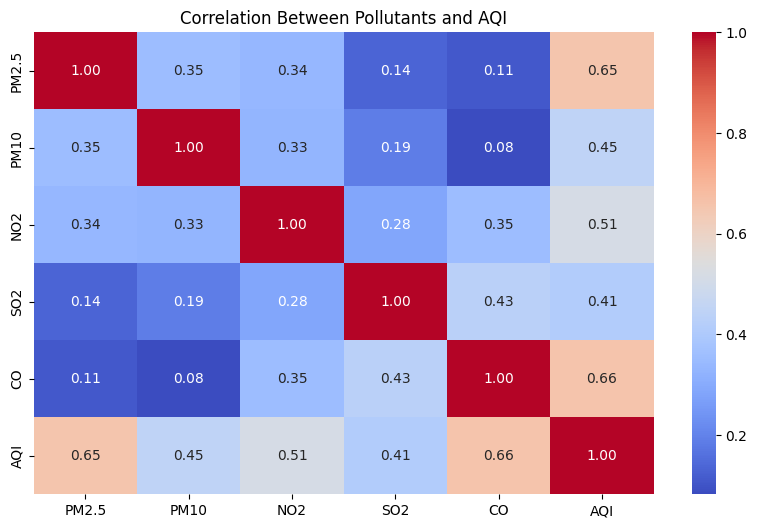

In [26]:
#Heatmap Visualization
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Pollutants and AQI")
plt.show()

In [27]:
plt.savefig("../visuals/correlation_heatmap.png")

<Figure size 640x480 with 0 Axes>

In [28]:
#Distribution of Air Quality Index(AQI)
fig = px.histogram(
    df, 
    x="AQI",
    nbins=50,
    title="Distribution of Air Quality Index (AQI)",
    color_discrete_sequence=["red"]
)

fig.update_layout(
    xaxis_title="AQI Value",
    yaxis_title="Frequency",
    template="plotly_dark"
)

fig.show()

In [29]:
fig.write_html("../visuals/aqi_distribution.html")

In [30]:
#Distribution of AQI Categories
def categorize_aqi(aqi):
    if aqi<=50:
        return "Good"
    elif aqi<=100:
        return "Satisfactory"
    elif aqi<=200:
        return "Moderate"
    elif aqi<=300:
        return "Poor"
    elif aqi<=400:
        return "Very Poor"
    else:
        return "Severe"

In [31]:
df["AQI_category"] = df["AQI"].apply(categorize_aqi)

In [32]:
aqi_category_count = df["AQI_category"].value_counts().reset_index()
aqi_category_count.columns = ["AQI_Category", "Count"]

aqi_category_count

,AQI_Category,Count
0,Satisfactory,10468
1,Moderate,9680
2,Poor,3108
3,Very Poor,3018
4,Good,1817
5,Severe,1440


In [33]:
fig = px.bar(
    aqi_category_count,
    x="AQI_Category",
    y="Count",
    title="Distribution of AQI Categories",
    color="AQI_Category"
)

fig.update_layout(
    xaxis_title="AQI Category",
    yaxis_title="Frequency",
    template="plotly_dark"
)

fig.show()

In [34]:
fig.write_html("../visuals/aqi_category_distribution.html")

In [35]:
# Monthly AQI Trend Analysis
df["Month"] = df["Date"].dt.month

In [36]:
monthly_aqi = df.groupby("Month")["AQI"].mean().reset_index()
monthly_aqi

,Month,AQI
0,1,214.531816
1,2,195.613350
2,3,165.123318
3,4,144.653590
4,5,139.388515
5,6,123.488083
6,7,116.855647
7,8,114.716322
8,9,115.913023
9,10,177.275298


In [37]:
import calendar
monthly_aqi["Month"] =  monthly_aqi["Month"].apply(lambda x:calendar.month_name[x])

In [38]:
fig = px.line(
    monthly_aqi,
    x="Month",
    y="AQI",
    title="Average AQI by Month",
    markers=True
)
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Average AQI",
    template="plotly_dark"
)
fig.show()

In [39]:
fig.write_html("../visuals/monthly_aqi_trend.html")

In [40]:
#Pollutant Impact Analysis
aqi_corr = corr_matrix["AQI"].sort_values(ascending=False)

aqi_corr

AQI      1.000000
CO       0.657894
PM2.5    0.653752
NO2      0.512671
PM10     0.446605
SO2      0.408996
Name: AQI, dtype: float64

In [41]:
aqi_corr = aqi_corr.drop("AQI")
aqi_corr

CO       0.657894
PM2.5    0.653752
NO2      0.512671
PM10     0.446605
SO2      0.408996
Name: AQI, dtype: float64

In [42]:
aqi_corr_df = aqi_corr.reset_index()
aqi_corr_df.columns = ["Pollutant", "Correlation"]

aqi_corr_df

,Pollutant,Correlation
0,CO,0.657894
1,PM2.5,0.653752
2,NO2,0.512671
3,PM10,0.446605
4,SO2,0.408996


In [43]:
fig = px.bar(
        aqi_corr_df,
        x="Pollutant",
        y="Correlation",
        title="Impact of Pollutants on AQI",
        color="Correlation",
        color_continuous_scale="Reds"
    )

fig.update_layout(
    xaxis_title="Pollutant",
    yaxis_title="Correlation With AQI",
    template="plotly_dark"
)

fig.show()


In [44]:
fig.write_html("../visuals/pollutant_impact.html")